# **Absenteeism at Work**
<subtitle> *Employee Segmentation using an adaptation of LRFM Analysis* </subtitle>

The **Absenteeism at Work** dataset, sourced from the UCI Machine Learning Repository ([UCI ID: 445](https://archive.ics.uci.edu/dataset/445/absenteeism+at+work)), records absenteeism events for employees at a courier company in Brazil from July 2007 to July 2010. This analysis adopts Absenteeism to adapt LRFM (Length, Recency, Frequency, Monetary) to an HR context. Guided by Claudio Marcus’s *"A practical yet meaningful approach to customer segmentation"* (1998), it segments employees by absence patterns to inform workplace strategies.

## **Dataset Description**
The dataset contains **740 rows** across **21 columns**, each row representing an employee absence event.

### Attribute Information

| Attribute Name                     | Description                                                                 | Data Type | Range/Values                          | LRFM Relevance                                                                 |
|------------------------------------|-----------------------------------------------------------------------------|-----------|---------------------------------------|--------------------------------------------------------------------------------|
| ID                                 | Unique employee identifier                                                  | Integer   | 1–36                                  | Groups absence events for Frequency and Monetary, like a customer ID.          |
| Reason for absence                 | Code for absence reason (e.g., medical, personal)                           | Integer   | 0–28 (0 = missing, 23 = medical, etc.) | Contextual; overlays segments (e.g., medical vs. personal absences).           |
| Month of absence                   | Month when absence occurred                                                 | Integer   | 0–12 (0 = missing, 1 = Jan, 12 = Dec) | Approximates dates for Length (first to last absence) and Recency.             |
| Day of the week                    | Day of absence (Monday–Friday)                                              | Integer   | 2–6 (2 = Mon, 3 = Tue, ..., 6 = Fri)  | Supports temporal patterns; secondary to LRFM.                                  |
| Seasons                            | Season of absence                                                           | Integer   | 1–4 (1 = summer, 2 = autumn, 3 = winter, 4 = spring) | Contextual; not core to LRFM.                                                  |
| Transportation expense             | Monthly transportation cost to work (BRL)                                   | Integer   | 118–378                               | Potential proxy for Monetary cost (e.g., hours × expense rate).                 |
| Distance from Residence to Work    | Distance to workplace (km)                                                  | Integer   | 5–52                                  | Contextual; may explain absence patterns, not LRFM-direct.                     |
| Service time                       | Years of service/tenure                                                     | Integer   | 1–29                                  | Alternative for Length or segment overlay (e.g., veteran vs. new employees).   |
| Age                                | Employee’s age                                                              | Integer   | 27–58                                 | Demographic context; not core to LRFM.                                         |
| Work load Average/day              | Average daily workload (unit unclear)                                       | Float     | ~200,000–700,000                     | Contextual; may link to stress-related absences, not LRFM.                     |
| Hit target                         | Percentage of daily target achieved                                         | Integer   | 81–100                                | Performance context; secondary to LRFM.                                        |
| Disciplinary failure               | Absence due to disciplinary issues (0 = no, 1 = yes)                        | Integer   | 0–1                                   | Filters non-standard absences for cleaner LRFM metrics.                        |
| Education                          | Education level (1 = high school, 2 = graduate, 3 = postgraduate, 4 = master/doctor) | Integer   | 1–4                                   | Demographic context; not LRFM-direct.                                          |
| Son                                | Number of children                                                          | Integer   | 0–4                                   | Personal context; not LRFM.                                                    |
| Social drinker                     | Social drinking status (0 = no, 1 = yes)                                    | Integer   | 0–1                                   | Lifestyle context; not LRFM.                                                   |
| Social smoker                      | Social smoking status (0 = no, 1 = yes)                                     | Integer   | 0–1                                   | Lifestyle context; not LRFM.                                                   |
| Pet                                | Number of pets                                                              | Integer   | 0–8                                   | Personal context; not LRFM.                                                    |
| Weight                             | Employee’s weight (kg)                                                      | Integer   | 56–108                                | Health context; not LRFM.                                                     |
| Height                             | Employee’s height (cm)                                                      | Integer   | 163–199                               | Health context; not LRFM.                                                     |
| Body mass index                    | BMI                                                                         | Integer   | 19–38                                 | Health context; not LRFM.                                                     |
| Absenteeism time in hours          | Hours absent per event                                                      | Integer   | 0–120                                 | Core for Monetary (sum of hours or cost), measures absence impact.             |

## **Importing Necessary Libraries**

In [1]:
import numpy as np
import pandas as pd
import datetime as dt

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
sns.set_theme(style = 'ticks', palette = 'deep')

## **Importing the Dataset**

In [3]:
df = pd.read_csv('Absenteeism_at_work.csv', sep = ';')

In [4]:
df.shape

(740, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   ID                               740 non-null    int64  
 1   Reason for absence               740 non-null    int64  
 2   Month of absence                 740 non-null    int64  
 3   Day of the week                  740 non-null    int64  
 4   Seasons                          740 non-null    int64  
 5   Transportation expense           740 non-null    int64  
 6   Distance from Residence to Work  740 non-null    int64  
 7   Service time                     740 non-null    int64  
 8   Age                              740 non-null    int64  
 9   Work load Average/day            740 non-null    float64
 10  Hit target                       740 non-null    int64  
 11  Disciplinary failure             740 non-null    int64  
 12  Education             

## **Data Cleaning**

In [6]:
df.isnull().sum() # check for missing values

ID                                 0
Reason for absence                 0
Month of absence                   0
Day of the week                    0
Seasons                            0
Transportation expense             0
Distance from Residence to Work    0
Service time                       0
Age                                0
Work load Average/day              0
Hit target                         0
Disciplinary failure               0
Education                          0
Son                                0
Social drinker                     0
Social smoker                      0
Pet                                0
Weight                             0
Height                             0
Body mass index                    0
Absenteeism time in hours          0
dtype: int64

There are no missing values present across 21 attributes. This confirmed that the dataset is overall clean for aggregation and segmentation

In [7]:
# check for month of absence where month of absence is 0 (invalid month)
df[df['Month of absence'] == 0]

,ID,Reason for absence,Month of absence,Day of the week,Seasons,Transportation expense,Distance from Residence to Work,Service time,Age,Work load Average/day,...,Disciplinary failure,Education,Son,Social drinker,Social smoker,Pet,Weight,Height,Body mass index,Absenteeism time in hours
737,4,0,0,3,1,118,14,13,40,271.219,...,0,1,1,1,0,8,98,170,34,0
738,8,0,0,4,2,231,35,14,39,271.219,...,0,1,2,1,0,2,100,170,35,0
739,35,0,0,6,3,179,45,14,53,271.219,...,0,1,1,0,0,1,77,175,25,0


In [8]:
# remove rows with invalid month of absence
df = df[df['Month of absence'] != 0]

In [9]:
# check for absenteeism time in hours is 0 (no actual absence)
df[df['Absenteeism time in hours'] == 0]

,ID,Reason for absence,Month of absence,Day of the week,Seasons,Transportation expense,Distance from Residence to Work,Service time,Age,Work load Average/day,...,Disciplinary failure,Education,Son,Social drinker,Social smoker,Pet,Weight,Height,Body mass index,Absenteeism time in hours
1,36,0,7,3,1,118,13,18,50,239.554,...,1,1,1,1,0,0,98,178,31,0
50,20,0,9,2,4,260,50,11,36,241.476,...,1,1,4,1,0,0,65,168,23,0
51,29,0,9,2,4,225,26,9,28,241.476,...,1,1,1,0,0,2,69,169,24,0
54,11,0,9,3,4,289,36,13,33,241.476,...,1,1,2,1,0,1,90,172,30,0
55,36,0,9,3,4,118,13,18,50,241.476,...,1,1,1,1,0,0,98,178,31,0
58,13,0,9,4,4,369,17,12,31,241.476,...,1,1,3,1,0,0,70,169,25,0
64,36,0,10,4,4,118,13,18,50,253.465,...,1,1,1,1,0,0,98,178,31,0
134,34,27,1,2,2,118,10,10,37,308.593,...,0,1,0,0,0,0,83,172,28,0
203,2,0,4,2,3,235,29,12,48,326.452,...,1,1,1,0,1,5,88,163,33,0
213,7,0,5,4,3,279,5,14,39,378.884,...,1,1,2,1,1,0,68,168,24,0


In [10]:
# remove rows with no actual absence
df = df[df['Absenteeism time in hours'] != 0]

## **Exploratory Data Analysis**

In [ ]:
# Distribution of 'Absenteeism time in hours'
df['Absenteeism time in hours'].describe()

count    696.000000
mean       7.362069
std       13.628618
min        1.000000
25%        2.000000
50%        3.000000
75%        8.000000
max      120.000000
Name: Absenteeism time in hours, dtype: float64

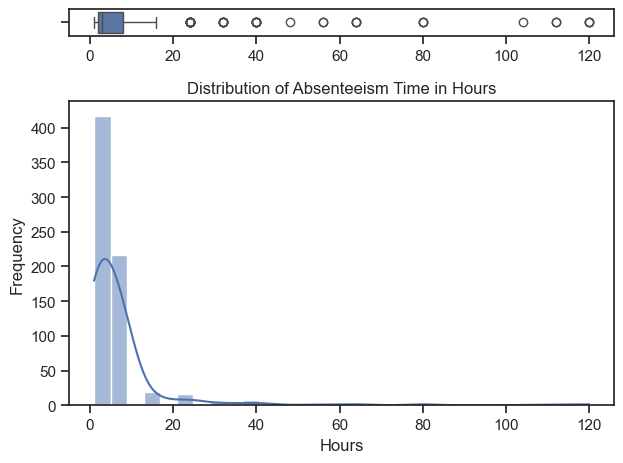

In [12]:
ax_box = plt.subplot2grid((5, 1), (0, 0), rowspan = 1)
ax_hist = plt.subplot2grid((5, 1), (1, 0), rowspan = 4)

# Boxplot
sns.boxplot(data = df, x = 'Absenteeism time in hours', ax = ax_box)
ax_box.set_title('')
ax_box.set_xlabel('')

# Histogram
sns.histplot(df['Absenteeism time in hours'], bins = 30, kde = True, ax = ax_hist)
ax_hist.set_title('Distribution of Absenteeism Time in Hours')
ax_hist.set_xlabel('Hours')
ax_hist.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [13]:
Q1 = df['Absenteeism time in hours'].quantile(0.25)
Q2 = df['Absenteeism time in hours'].quantile(0.50)
Q3 = df['Absenteeism time in hours'].quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - (1.5 * IQR)
upper_fence = Q3 + (1.5 * IQR)

lower_outliers = len(df['Absenteeism time in hours'] < lower_fence)
upper_outliers = len(df['Absenteeism time in hours'] > upper_fence)

print('Measure of Central Tendency of Absenteeism Time in Hours: \n')
print('First Quartile: ', Q1)
print('Median: ', Q2)
print('First Quartile: ', Q3)
print('Interquartile Range: ', IQR)
print('Outliers: ', lower_outliers + upper_outliers)

Measure of Central Tendency of Absenteeism Time in Hours: 

First Quartile:  2.0
Median:  3.0
First Quartile:  8.0
Interquartile Range:  6.0
Outliers:  1392


The distribution plot of the absenteeism time in hours shows a median of 2-3 hours and is skewed to the right.

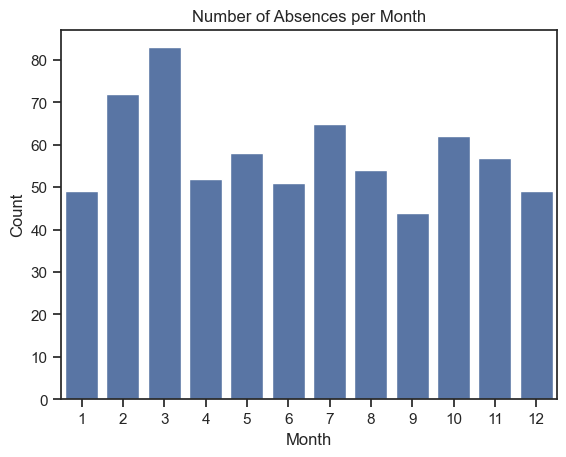

In [14]:
# Number of absences per month
sns.countplot(x = 'Month of absence', data = df)
plt.title('Number of Absences per Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.show()

In [15]:
# Number of unique employees
print("Unique Employees")
unique_employees = df['ID'].nunique()
print(f"Number of unique employees: {unique_employees}\n")
print(f"Observation: With {unique_employees} employees, the dataset captures multiple absences per individual.\n")

Unique Employees
Number of unique employees: 33

Observation: With 33 employees, the dataset captures multiple absences per individual.



In [16]:
# Absences per employee
print("Absences per Employee")
absences_per_employee = df['ID'].value_counts()
print("Absences per employee statistics:\n", absences_per_employee.describe(), "\n")
print("Observation: Variability exists; some employees have significantly more absences.\n")

Absences per Employee
Absences per employee statistics:
 count     33.000000
mean      21.090909
std       23.867294
min        2.000000
25%        5.000000
50%       13.000000
75%       29.000000
max      112.000000
Name: count, dtype: float64 

Observation: Variability exists; some employees have significantly more absences.



In [17]:
# Most common reasons for absence
print("Common Reasons for Absence")
reason_counts = df['Reason for absence'].value_counts().sort_index(ascending = True)
print("Most common reasons for absence:\n", reason_counts, "\n")
print("Observation: Certain reasons dominate, which could inform contextual understanding.\n")

Common Reasons for Absence
Most common reasons for absence:
 Reason for absence
1      16
2       1
3       1
4       2
5       3
6       8
7      15
8       6
9       4
10     25
11     26
12      8
13     55
14     19
15      2
16      3
17      1
18     21
19     40
21      6
22     38
23    149
24      3
25     31
26     33
27     68
28    112
Name: count, dtype: int64 

Observation: Certain reasons dominate, which could inform contextual understanding.



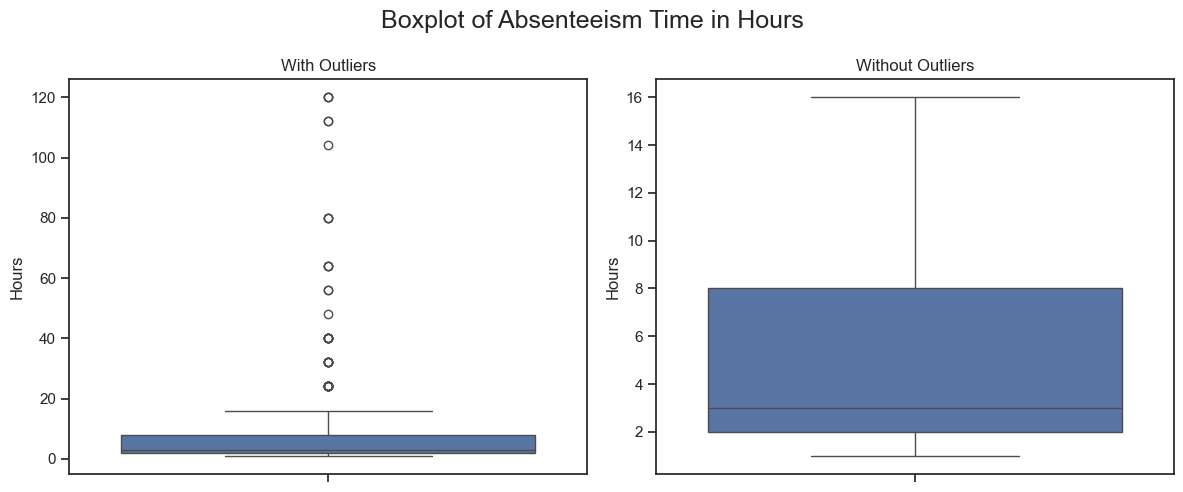

Observation: Outliers exist with very high hours (e.g., >100), which may impact LRFM Monetary values.



In [18]:
# Boxplot for 'Absenteeism time in hours' (standalone, kept for comparison)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y ='Absenteeism time in hours', data = df, ax = ax1)
ax1.set_title('With Outliers')
ax1.set_ylabel('Hours')

sns.boxplot(y = 'Absenteeism time in hours', data = df, ax = ax2, showfliers = False)
ax2.set_title('Without Outliers')
ax2.set_ylabel('Hours')

plt.suptitle('Boxplot of Absenteeism Time in Hours', fontsize = 18)
plt.tight_layout()
plt.show()
print("Observation: Outliers exist with very high hours (e.g., >100), which may impact LRFM Monetary values.\n")

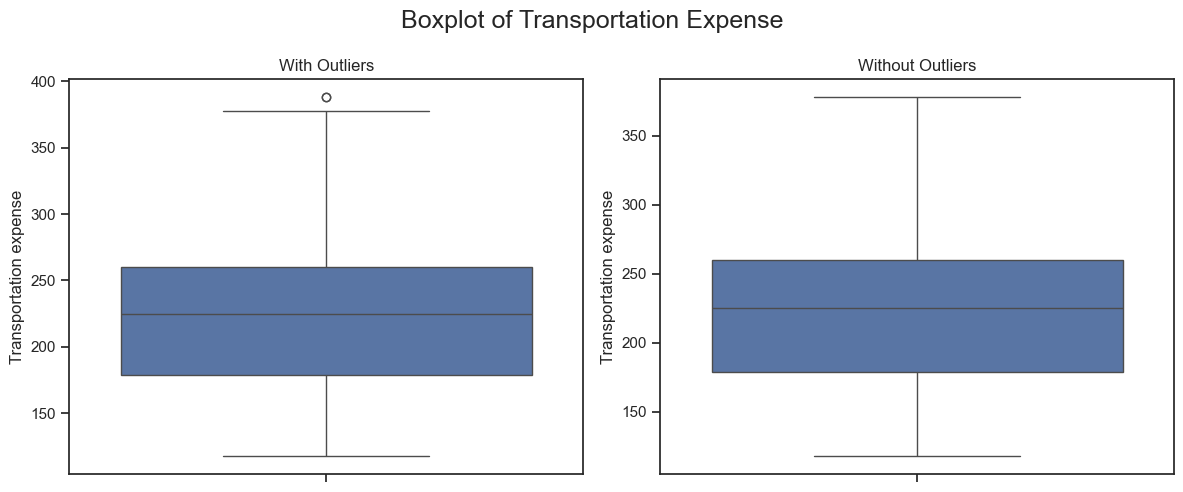

Observation: Some variation, but not much of extreme outliers in transportation costs.



In [19]:
# Boxplot for 'Transportation expense'
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y ='Transportation expense', data = df, ax = ax1)
ax1.set_title('With Outliers')

sns.boxplot(y = 'Transportation expense', data = df, ax = ax2, showfliers = False)
ax2.set_title('Without Outliers')

plt.suptitle('Boxplot of Transportation Expense', fontsize = 18)
plt.tight_layout()
plt.show()
print("Observation: Some variation, but not much of extreme outliers in transportation costs.\n")

Correlation Analysis


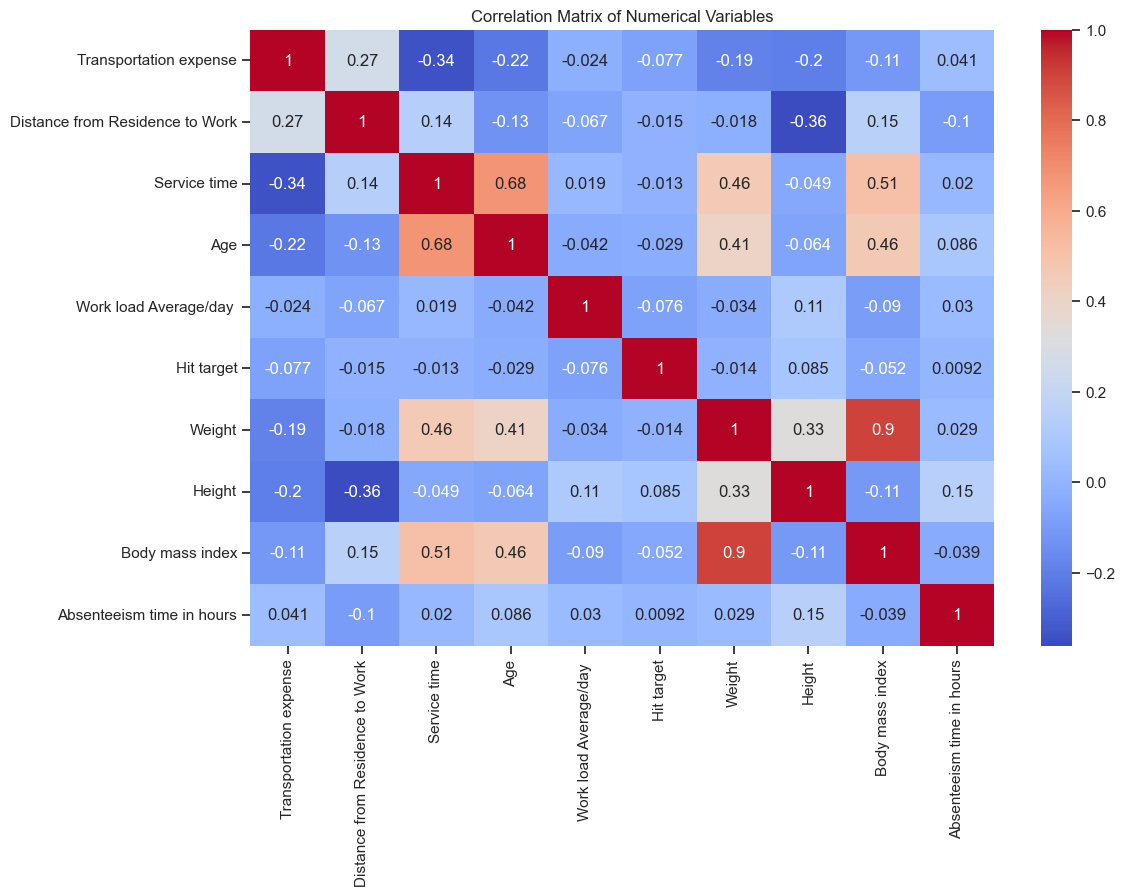

Observation: No strong correlations directly affect LRFM, but 'Age' and 'Service time' are related.



In [20]:
# Correlation matrix of numerical variables
print("Correlation Analysis")
numerical_cols = ['Transportation expense', 'Distance from Residence to Work', 'Service time', 'Age', 
                  'Work load Average/day ', 'Hit target', 'Weight', 'Height', 'Body mass index', 
                  'Absenteeism time in hours']
corr_matrix = df[numerical_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Variables')
plt.show()
print("Observation: No strong correlations directly affect LRFM, but 'Age' and 'Service time' are related.\n")

## **LRFM Analysis**

In [21]:
# Calculate LRFM Metrics

print('Calculating LRFM Metrics: ')
lrfm = df.groupby('ID').agg(
    Length = ('Month of absence', 'nunique'), # unique months absent
    Last_Month = ('Month of absence', 'max'), # most recent absence month
    Frequency = ('ID', 'count'), # number of absence records
    Monetary = ('Absenteeism time in hours', 'sum') # total hours absent
)

print('LRFM table preview: \n', lrfm.head(), '\n')

Calculating LRFM Metrics: 
LRFM table preview: 
     Length  Last_Month  Frequency  Monetary
ID                                         
1       10          12         22       121
2        2           8          4        25
3       12          12        112       482
5        9          12         14       104
6        5          11          8        72 



In [22]:
# Calculating Recency
# month since last absence, assuming reference month is 12 (December)
lrfm['Recency'] = 12 - lrfm['Last_Month']
lrfm = lrfm.drop('Last_Month', axis = 1)
print('Recency calculated with reference month 12. LRFM table updated: \n', lrfm.head(), '\n')

Recency calculated with reference month 12. LRFM table updated: 
     Length  Frequency  Monetary  Recency
ID                                      
1       10         22       121        0
2        2          4        25        4
3       12        112       482        0
5        9         14       104        0
6        5          8        72        1 



In [23]:
# Segment Employees
print('Segmenting Employees:')
freq_median = lrfm['Frequency'].median()
mon_median = lrfm['Monetary'].median()

print(f'Frequency median: {freq_median}, Monetary median: {mon_median}')

lrfm['Freq_Segment'] = lrfm['Frequency'].apply(lambda x: 'High' if x > freq_median else 'Low')
lrfm['Mon_Segment'] = lrfm['Monetary'].apply(lambda x: 'High' if x > mon_median else 'Low')
lrfm['Segment'] = lrfm['Freq_Segment'] + '-' + lrfm['Mon_Segment']

segment_names = {
    'High-High': 'Chronic Absentees',
    'High-Low': 'Frequent Short Absentees',
    'Low-High': 'Rare Long Absentees',
    'Low-Low': 'Low-Impact Absentees'
}
lrfm['Segment_Name'] = lrfm['Segment'].map(segment_names)
print("Segmented LRFM table preview:\n", lrfm.head(), "\n")

Segmenting Employees:
Frequency median: 13.0, Monetary median: 104.0
Segmented LRFM table preview:
     Length  Frequency  Monetary  Recency Freq_Segment Mon_Segment    Segment  \
ID                                                                             
1       10         22       121        0         High        High  High-High   
2        2          4        25        4          Low         Low    Low-Low   
3       12        112       482        0         High        High  High-High   
5        9         14       104        0         High         Low   High-Low   
6        5          8        72        1          Low         Low    Low-Low   

                Segment_Name  
ID                            
1          Chronic Absentees  
2       Low-Impact Absentees  
3          Chronic Absentees  
5   Frequent Short Absentees  
6       Low-Impact Absentees   



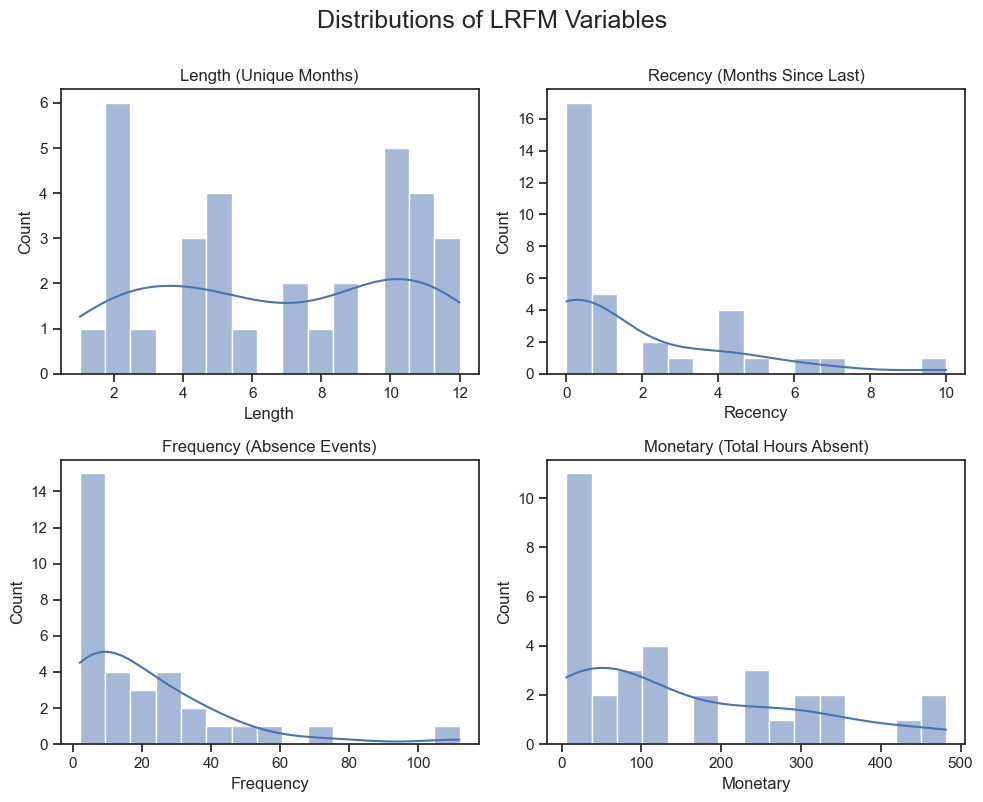

Observation: Distributions show the spread of EA-LRFM metrics, highlighting skewness or outliers that may influence segmentation.



In [24]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Flatten axes for easier indexing
axes = axes.flatten()

# List of variables and titles
variables = ['Length', 'Recency', 'Frequency', 'Monetary']
titles = ['Length (Unique Months)', 'Recency (Months Since Last)', 'Frequency (Absence Events)', 'Monetary (Total Hours Absent)']

# Plot histogram for each variable
for i, (var, title) in enumerate(zip(variables, titles)):
    sns.histplot(lrfm[var], bins=15, kde=True, ax=axes[i])
    axes[i].set_title(title)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Count')

# Adjust layout
plt.suptitle('Distributions of LRFM Variables', fontsize = 18, y=1)
plt.tight_layout()
plt.show()
print("Observation: Distributions show the spread of EA-LRFM metrics, highlighting skewness or outliers that may influence segmentation.\n")

## **Visualize LRFM Results**

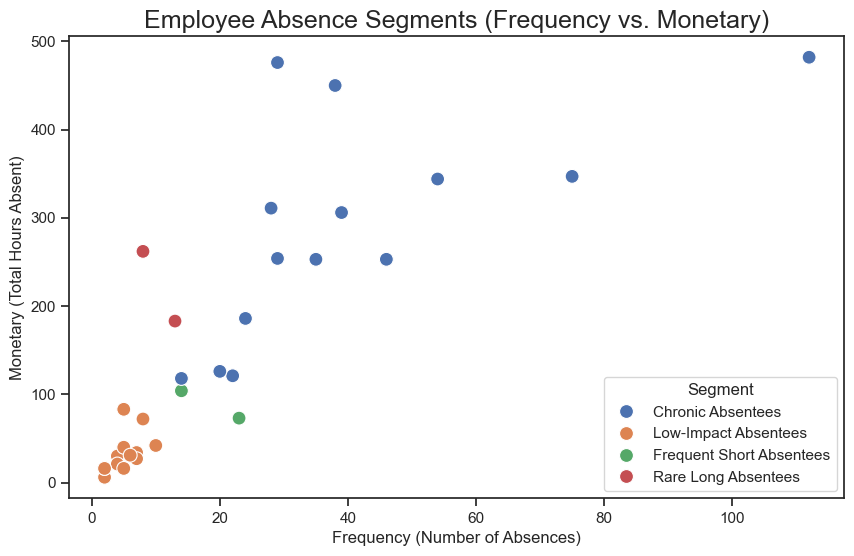

In [25]:
# Scatter plot: Frequency vs. Monetary
plt.figure(figsize = (10, 6))
sns.scatterplot(data = lrfm, x = 'Frequency', y = 'Monetary', hue = 'Segment_Name', s=100)
plt.title('Employee Absence Segments (Frequency vs. Monetary)', fontsize = 18)
plt.xlabel('Frequency (Number of Absences)')
plt.ylabel('Monetary (Total Hours Absent)')
plt.legend(title = 'Segment')
plt.show()

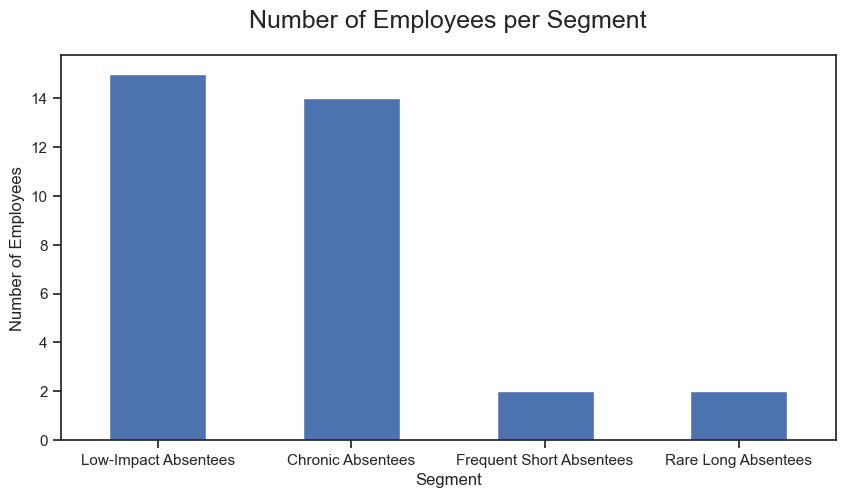

In [26]:
# Bar chart: Number of employees per segment
plt.figure(figsize=(10, 5))
segment_counts = lrfm['Segment_Name'].value_counts()
segment_counts.plot(kind='bar')
plt.title('Number of Employees per Segment', fontsize = 18, y = 1.05)
plt.xlabel('Segment')
plt.ylabel('Number of Employees')
plt.xticks(rotation=360)
plt.show()

The scatterplot and bar chart shows the cluster segment of each employee based on their ID of their cluster segment and the number of employees based on the segment:
1. **Chronic Absentees**
    - High frequency and high monetary loss
    - These employees are absent frequently and for long durations - often the most costly segment to the company.
2. **Low-Impact Absentees**
    - Low frequency and low monetary loss
    - These employees are rarely absend and when they are, it is brief - they pose minimal impact to the company's monetary
3. **Frequen Short Absentees**
    - High frequency, but relatively low hours lost
    - May signal employees who are frequently sick or take short leave - not very costly but could affect team consistency
4. **Rare Long Absentees**
    - Low frequency, high hours lost
    - Absent infrequently, but when they are, it is for a long stretch - often due to serious illness or personal matters.

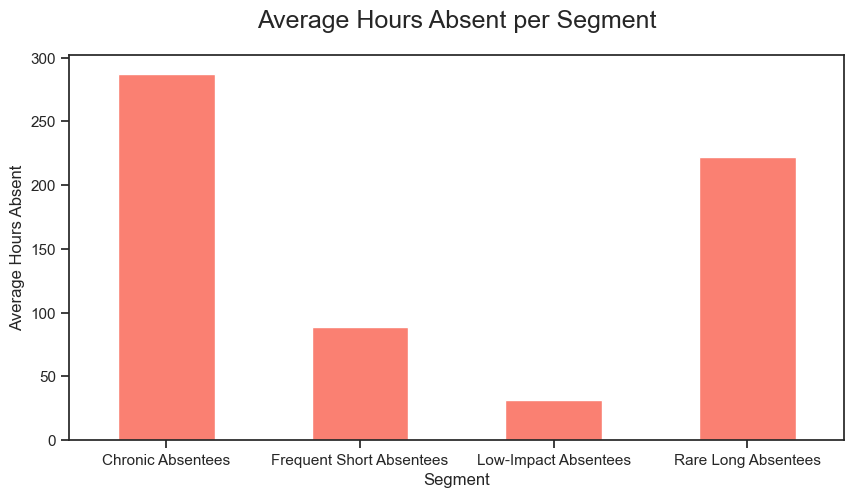

In [27]:
# Bar chart: Average hours absent per segment
plt.figure(figsize=(10, 5))
avg_hours = lrfm.groupby('Segment_Name')['Monetary'].mean()
avg_hours.plot(kind='bar', color='salmon')
plt.title('Average Hours Absent per Segment', fontsize = 18, y = 1.05)
plt.xlabel('Segment')
plt.ylabel('Average Hours Absent')
plt.xticks(rotation=360)
plt.show()

1. Reason for Absence by Segment


<Figure size 1000x600 with 0 Axes>

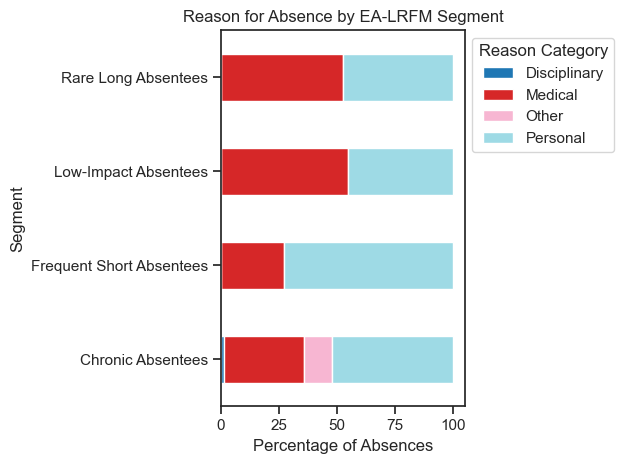

Observation: Medical reasons may dominate certain segments, suggesting health-focused interventions.



In [28]:
# Reason for Absence
print("1. Reason for Absence by Segment")
# Categorize reasons (simplified based on UCI documentation)
def categorize_reason(code):
    if code in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]:
        return 'Medical'
    elif code in [22, 23, 24, 25, 26, 28]:
        return 'Personal'
    elif code == 21:
        return 'Disciplinary'
    else:
        return 'Other'

df['Reason_Category'] = df['Reason for absence'].apply(categorize_reason)
# Merge with lrfm segments
df_with_segments = df.merge(lrfm[['Segment_Name']], left_on='ID', right_index=True)
# Count reasons by segment
reason_counts = df_with_segments.groupby(['Segment_Name', 'Reason_Category']).size().unstack(fill_value=0)
# Normalize to percentages
reason_percent = reason_counts.div(reason_counts.sum(axis=1), axis=0) * 100

# Plot stacked bar chart
plt.figure(figsize=(10, 6))
reason_percent.plot(kind='barh', stacked=True, colormap='tab20')
plt.title('Reason for Absence by EA-LRFM Segment')
plt.xlabel('Percentage of Absences')
plt.ylabel('Segment')
plt.legend(title='Reason Category', loc='best', bbox_to_anchor=(1, 1))
# plt.xticks(rotation = 360)
plt.tight_layout()
plt.show()
print("Observation: Medical reasons may dominate certain segments, suggesting health-focused interventions.\n")

This horizontal stacked bar chart shows the distribution of absence reasons within each employee segment:
1. Chronic Absentees
    - Absences are spread across personal, medical, and some “other” reasons.
    - This diversity of reasons suggests more complex, possibly systemic issues — from personal struggles to disengagement.

2. Frequent Short Absentees
    - Primarily absent for personal reasons, with a significant portion also medical.
    - Might reflect recurring short-term issues (family needs, mental health, minor illness).

3. Low-Impact Absentees
    - Evenly split between medical and personal reasons.
    - Indicates a balanced group, with fewer red flags.

4. Rare Long Absentees
    - Mostly medical and personal reasons — rarely disciplinary
    - Suggests these are serious, one-time or infrequent absences due to significant life or health events.

Demographic and Work Context Analysis


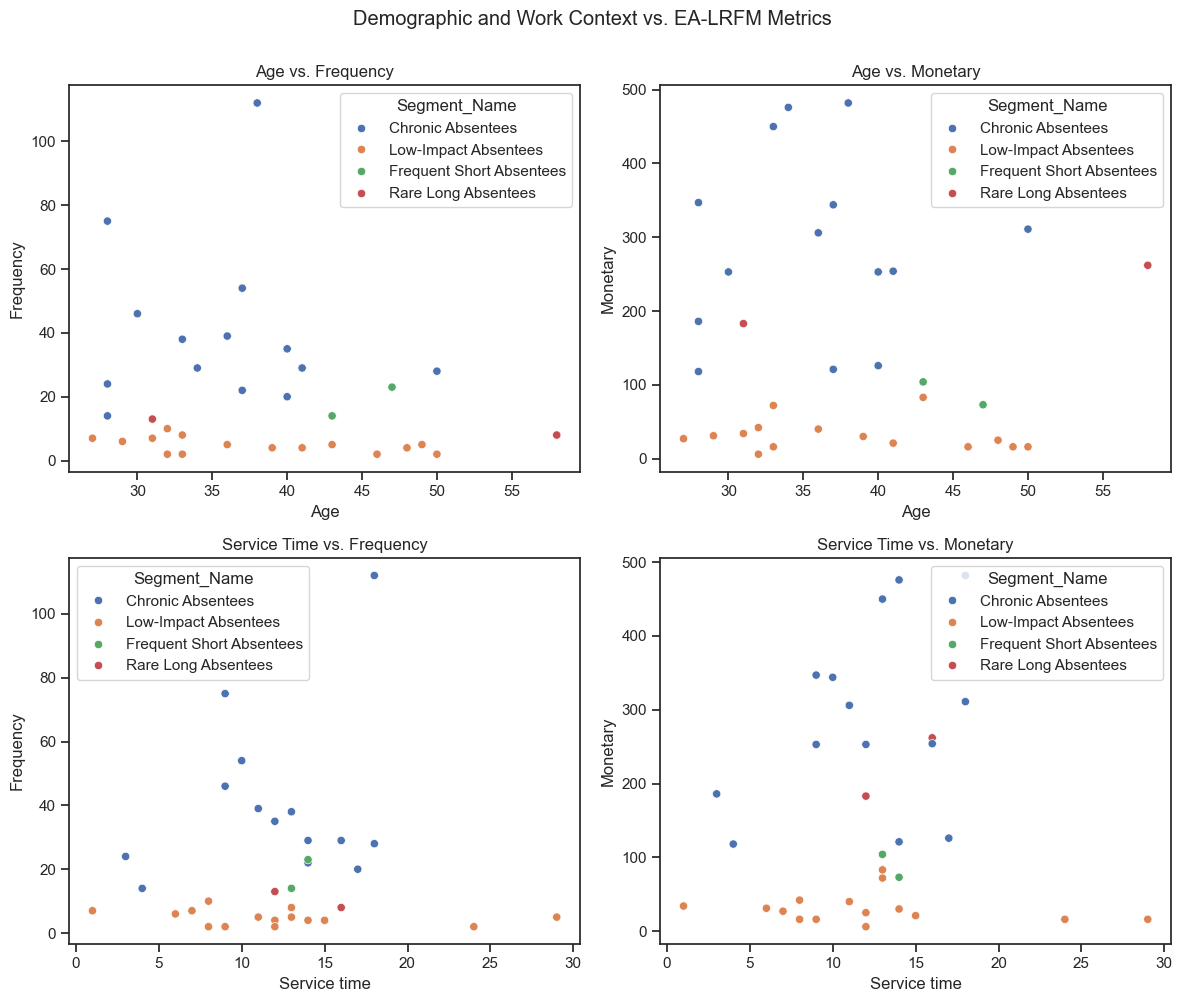

In [29]:
# Demographic and Work Context Overlay
print("Demographic and Work Context Analysis")
# Merge Age and Service time with lrfm
lrfm_with_context = lrfm.merge(df[['ID', 'Age', 'Service time']].drop_duplicates(), left_index=True, right_on='ID')

# Scatter plots: Age and Service time vs. Frequency/Monetary
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.scatterplot(data=lrfm_with_context, x='Age', y='Frequency', hue='Segment_Name', ax=axes[0, 0])
axes[0, 0].set_title('Age vs. Frequency')
sns.scatterplot(data=lrfm_with_context, x='Age', y='Monetary', hue='Segment_Name', ax=axes[0, 1])
axes[0, 1].set_title('Age vs. Monetary')
sns.scatterplot(data=lrfm_with_context, x='Service time', y='Frequency', hue='Segment_Name', ax=axes[1, 0])
axes[1, 0].set_title('Service Time vs. Frequency')
sns.scatterplot(data=lrfm_with_context, x='Service time', y='Monetary', hue='Segment_Name', ax=axes[1, 1])
axes[1, 1].set_title('Service Time vs. Monetary')
plt.suptitle('Demographic and Work Context vs. EA-LRFM Metrics', y=1)
plt.tight_layout()
plt.show()

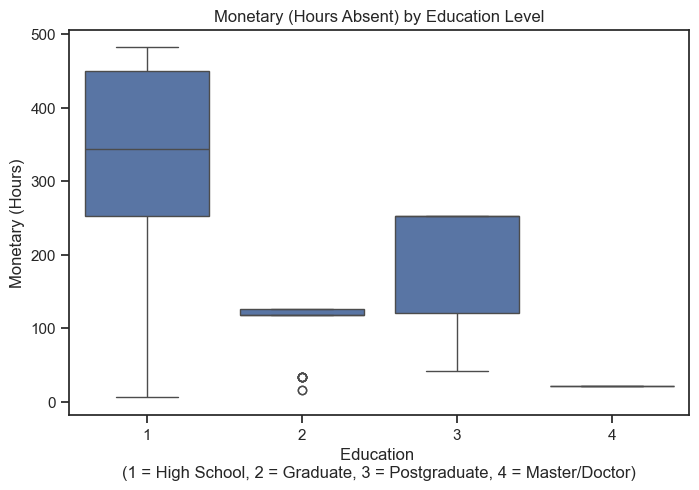

Observation: Younger employees or those with longer tenure may show distinct absence patterns; education levels could influence absence duration.



In [30]:
# Boxplot: Monetary by Education
# Ensure the Monetary column is merged into df_with_segments
df_with_segments['Monetary'] = df_with_segments['ID'].map(lrfm['Monetary'])

plt.figure(figsize=(8, 5))
sns.boxplot(x='Education', y='Monetary', data=df_with_segments)
plt.title('Monetary (Hours Absent) by Education Level')
plt.xlabel('Education \n(1 = High School, 2 = Graduate, 3 = Postgraduate, 4 = Master/Doctor)')
plt.ylabel('Monetary (Hours)')
plt.show()
print("Observation: Younger employees or those with longer tenure may show distinct absence patterns; education levels could influence absence duration.\n")

Employees that are high-school graduate have the highest monetary median, while the master/doctor show lower hours in median.

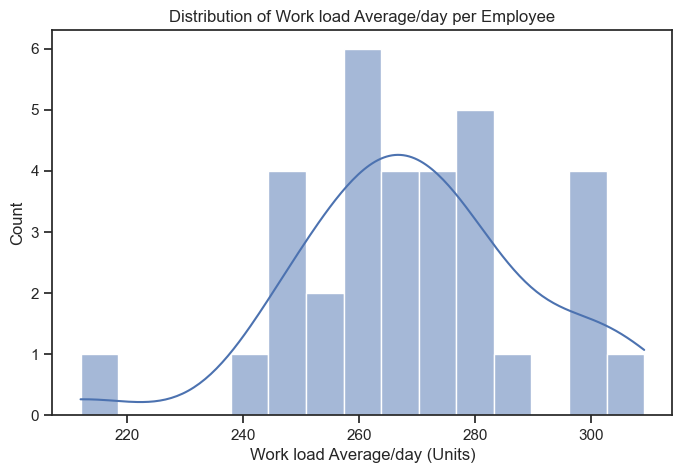

In [31]:
# Distribution of Work load Average/day
# Merge Work load Average/day with lrfm
workload_per_employee = df.groupby('ID')['Work load Average/day '].mean().reset_index()
lrfm_with_workload = lrfm.merge(workload_per_employee, left_index=True, right_on='ID')

plt.figure(figsize=(8, 5))
sns.histplot(lrfm_with_workload['Work load Average/day '], bins=15, kde=True)
plt.title('Distribution of Work load Average/day per Employee')
plt.xlabel('Work load Average/day (Units)')
plt.ylabel('Count')
plt.show()

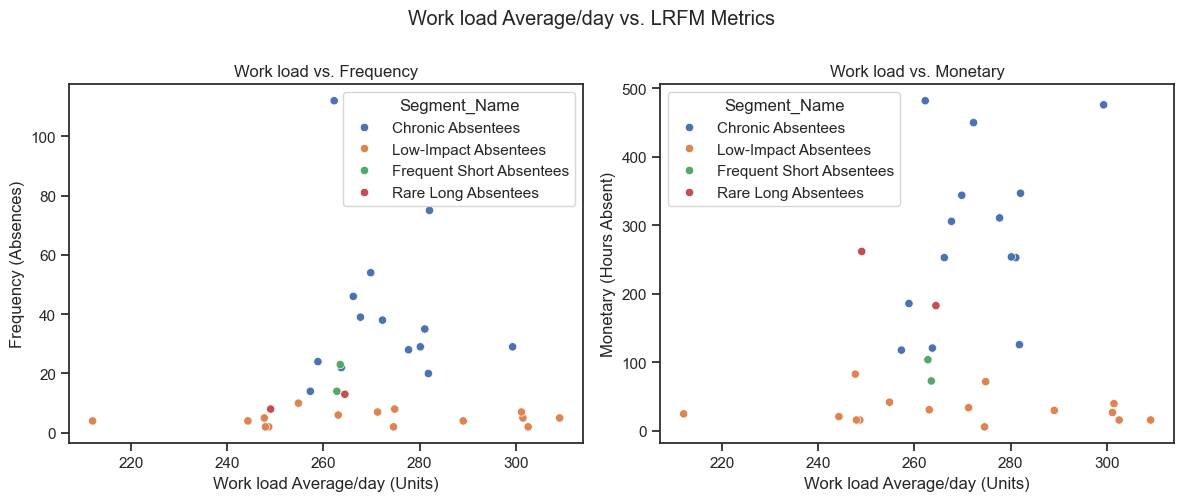

In [32]:
# Scatter plots: Work load vs. Frequency/Monetary
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(data=lrfm_with_workload, x='Work load Average/day ', y='Frequency', hue='Segment_Name', ax=ax1)
ax1.set_title('Work load vs. Frequency')
ax1.set_xlabel('Work load Average/day (Units)')
ax1.set_ylabel('Frequency (Absences)')

sns.scatterplot(data=lrfm_with_workload, x='Work load Average/day ', y='Monetary', hue='Segment_Name', ax=ax2)
ax2.set_title('Work load vs. Monetary')
ax2.set_xlabel('Work load Average/day (Units)')
ax2.set_ylabel('Monetary (Hours Absent)')

plt.suptitle('Work load Average/day vs. LRFM Metrics', y=1)
plt.tight_layout()
plt.show()

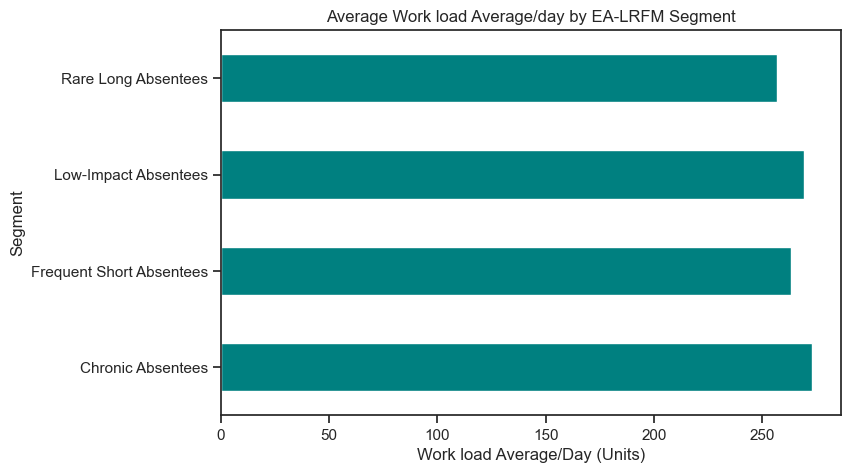

Observation: High workloads may correlate with specific segments, suggesting workload management as an HR intervention.



In [33]:
# Bar chart: Average workload by segment
avg_workload_by_segment = lrfm_with_workload.groupby('Segment_Name')['Work load Average/day '].mean()
plt.figure(figsize=(8, 5))
avg_workload_by_segment.plot(kind='barh', color='teal')
plt.title('Average Work load Average/day by EA-LRFM Segment')
plt.xlabel('Work load Average/Day (Units)')
plt.ylabel('Segment')
# plt.xticks(rotation=45)
plt.show()
print("Observation: High workloads may correlate with specific segments, suggesting workload management as an HR intervention.\n")